In [1]:
!pip install -q kagglehub
import kagglehub

path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")
print(f"Dataset downloaded to: {path}")

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Dataset downloaded to: /kaggle/input/heart-disease-data


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, classification_report
import warnings
warnings.filterwarnings('ignore')

dataset_path = '/kaggle/input/heart-disease-data'
files = os.listdir(dataset_path)
print("Files in dataset:")
for file in files:
    print(f"- {file}")

Files in dataset:
- heart_disease_uci.csv


In [3]:
df = pd.read_csv('/kaggle/input/heart-disease-data/heart_disease_uci.csv')

print("Dataset Shape:", df.shape)
print("\n" + "="*50)
print("First 5 rows:")
print(df.head())
print("\n" + "="*50)
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("Missing Values:")
print(df.isnull().sum())
print("\n" + "="*50)
print("Statistical Summary:")
print(df.describe())

Dataset Shape: (920, 16)

First 5 rows:
   id  age     sex    dataset               cp  trestbps   chol    fbs  \
0   1   63    Male  Cleveland   typical angina     145.0  233.0   True   
1   2   67    Male  Cleveland     asymptomatic     160.0  286.0  False   
2   3   67    Male  Cleveland     asymptomatic     120.0  229.0  False   
3   4   37    Male  Cleveland      non-anginal     130.0  250.0  False   
4   5   41  Female  Cleveland  atypical angina     130.0  204.0  False   

          restecg  thalch  exang  oldpeak        slope   ca  \
0  lv hypertrophy   150.0  False      2.3  downsloping  0.0   
1  lv hypertrophy   108.0   True      1.5         flat  3.0   
2  lv hypertrophy   129.0   True      2.6         flat  2.0   
3          normal   187.0  False      3.5  downsloping  0.0   
4  lv hypertrophy   172.0  False      1.4    upsloping  0.0   

                thal  num  
0       fixed defect    0  
1             normal    2  
2  reversable defect    1  
3             normal    

In [4]:
print("Target Variable Distribution (num):")
print(df['num'].value_counts().sort_index())
print("\n" + "="*50)
print("Target Percentage:")
print(df['num'].value_counts(normalize=True).sort_index() * 100)
print("\n" + "="*50)
print("Dataset Source Distribution:")
print(df['dataset'].value_counts())
print("\n" + "="*50)
print("Unique values in categorical columns:")
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\n{col}: {df[col].unique()}")

Target Variable Distribution (num):
num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

Target Percentage:
num
0    44.673913
1    28.804348
2    11.847826
3    11.630435
4     3.043478
Name: proportion, dtype: float64

Dataset Source Distribution:
dataset
Cleveland        304
Hungary          293
VA Long Beach    200
Switzerland      123
Name: count, dtype: int64

Unique values in categorical columns:

sex: ['Male' 'Female']

dataset: ['Cleveland' 'Hungary' 'Switzerland' 'VA Long Beach']

cp: ['typical angina' 'asymptomatic' 'non-anginal' 'atypical angina']

fbs: [True False nan]

restecg: ['lv hypertrophy' 'normal' 'st-t abnormality' nan]

exang: [False True nan]

slope: ['downsloping' 'flat' 'upsloping' nan]

thal: ['fixed defect' 'normal' 'reversable defect' nan]


Binary Target Distribution:
target
1    509
0    411
Name: count, dtype: int64

Binary Target Percentage:
target
1    55.326087
0    44.673913
Name: proportion, dtype: float64



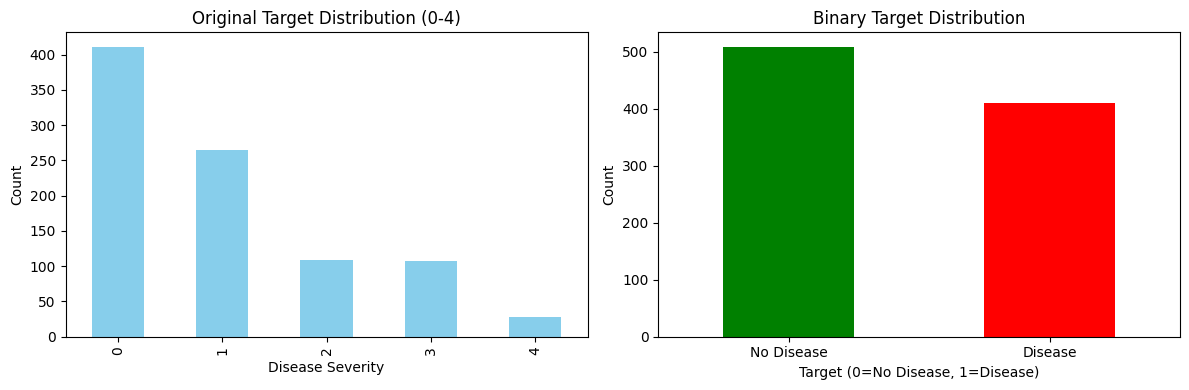

In [5]:
df['target'] = (df['num'] > 0).astype(int)

print("Binary Target Distribution:")
print(df['target'].value_counts())
print("\n" + "="*50)
print("Binary Target Percentage:")
print(df['target'].value_counts(normalize=True) * 100)
print("\n" + "="*50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['num'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Original Target Distribution (0-4)')
axes[0].set_xlabel('Disease Severity')
axes[0].set_ylabel('Count')

df['target'].value_counts().plot(kind='bar', ax=axes[1], color=['green', 'red'])
axes[1].set_title('Binary Target Distribution')
axes[1].set_xlabel('Target (0=No Disease, 1=Disease)')
axes[1].set_ylabel('Count')
axes[1].set_xticklabels(['No Disease', 'Disease'], rotation=0)

plt.tight_layout()
plt.show()

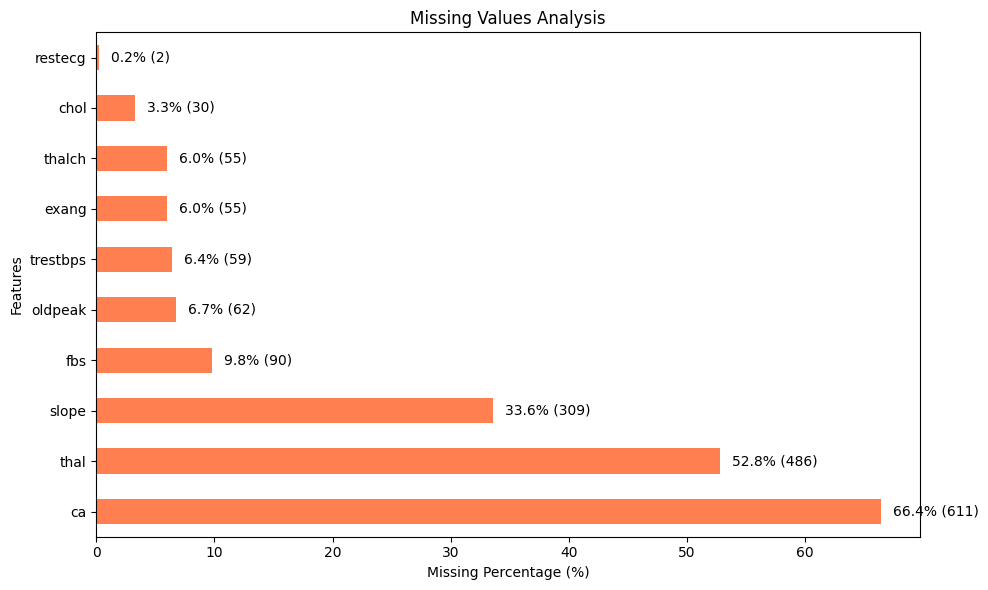

Missing Values Summary:
          Missing Count  Percentage
ca                  611   66.413043
thal                486   52.826087
slope               309   33.586957
fbs                  90    9.782609
oldpeak              62    6.739130
trestbps             59    6.413043
exang                55    5.978261
thalch               55    5.978261
chol                 30    3.260870
restecg               2    0.217391


In [6]:
plt.figure(figsize=(12, 6))
missing_data = df.isnull().sum().sort_values(ascending=False)
missing_percent = (missing_data / len(df)) * 100

missing_df = pd.DataFrame({'Missing Count': missing_data, 'Percentage': missing_percent})
missing_df = missing_df[missing_df['Missing Count'] > 0]

ax = missing_df['Percentage'].plot(kind='barh', color='coral', figsize=(10, 6))
plt.xlabel('Missing Percentage (%)')
plt.ylabel('Features')
plt.title('Missing Values Analysis')

for i, (index, value) in enumerate(missing_df['Percentage'].items()):
    plt.text(value + 1, i, f'{value:.1f}% ({int(missing_df.loc[index, "Missing Count"])})', va='center')

plt.tight_layout()
plt.show()

print("Missing Values Summary:")
print(missing_df)

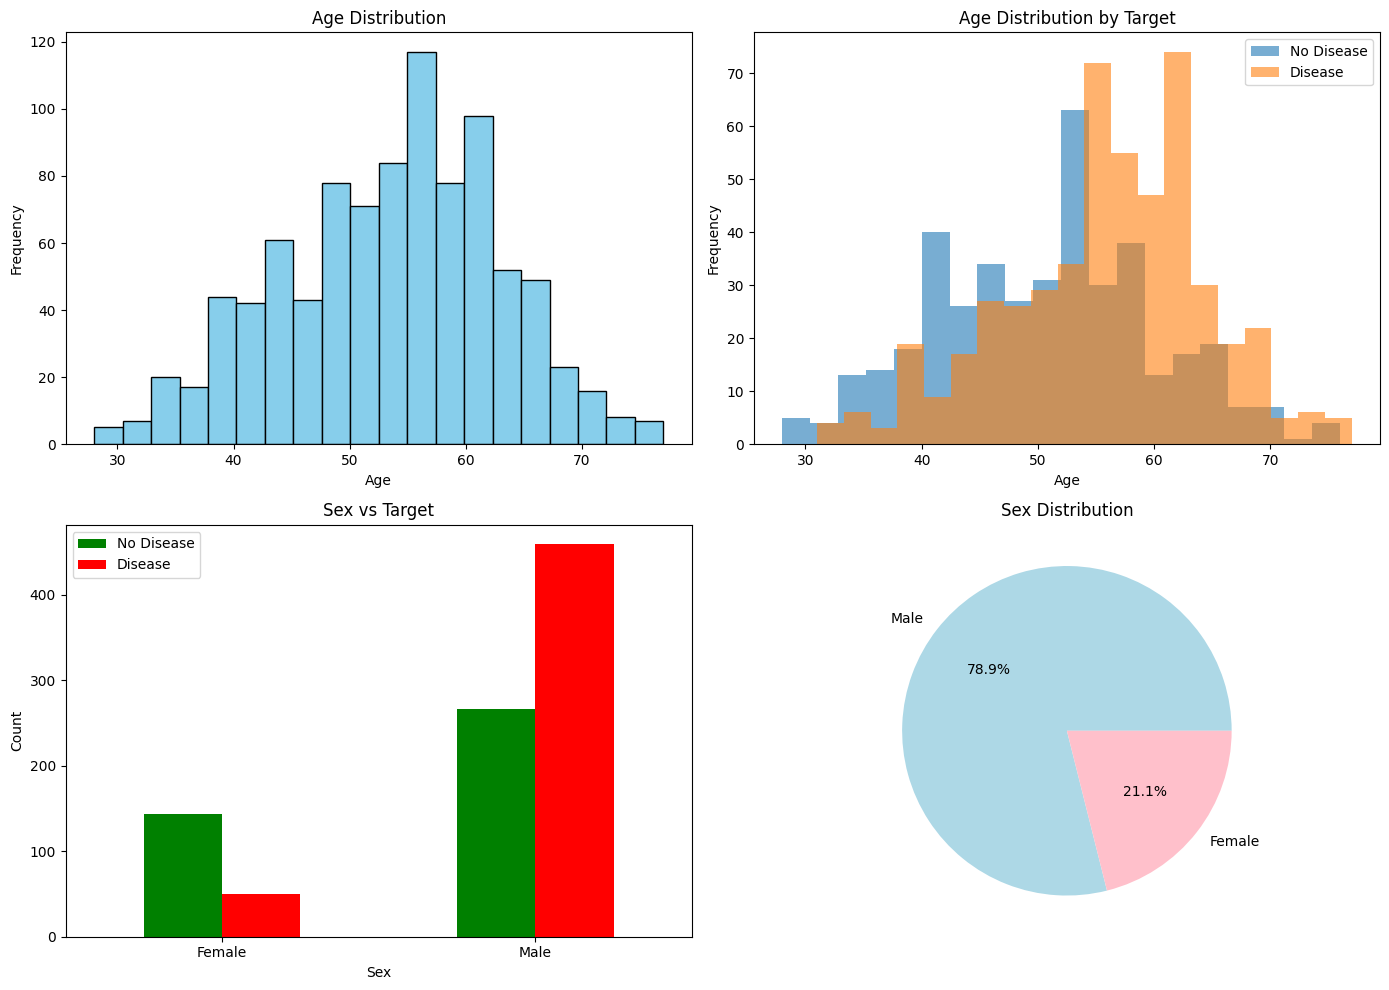

Age Statistics by Target:
        count       mean       std   min   25%   50%   75%   max
target                                                          
0       411.0  50.547445  9.433700  28.0  43.0  51.0  57.0  76.0
1       509.0  55.903733  8.718959  31.0  51.0  57.0  62.0  77.0


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df['age'].plot(kind='hist', bins=20, ax=axes[0, 0], color='skyblue', edgecolor='black')
axes[0, 0].set_title('Age Distribution')
axes[0, 0].set_xlabel('Age')
axes[0, 0].set_ylabel('Frequency')

df.groupby('target')['age'].plot(kind='hist', bins=20, ax=axes[0, 1], alpha=0.6, legend=True)
axes[0, 1].set_title('Age Distribution by Target')
axes[0, 1].set_xlabel('Age')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].legend(['No Disease', 'Disease'])

sex_target = pd.crosstab(df['sex'], df['target'])
sex_target.plot(kind='bar', ax=axes[1, 0], color=['green', 'red'])
axes[1, 0].set_title('Sex vs Target')
axes[1, 0].set_xlabel('Sex')
axes[1, 0].set_ylabel('Count')
axes[1, 0].legend(['No Disease', 'Disease'])
axes[1, 0].set_xticklabels(axes[1, 0].get_xticklabels(), rotation=0)

df['sex'].value_counts().plot(kind='pie', ax=axes[1, 1], autopct='%1.1f%%', colors=['lightblue', 'pink'])
axes[1, 1].set_title('Sex Distribution')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

print("Age Statistics by Target:")
print(df.groupby('target')['age'].describe())

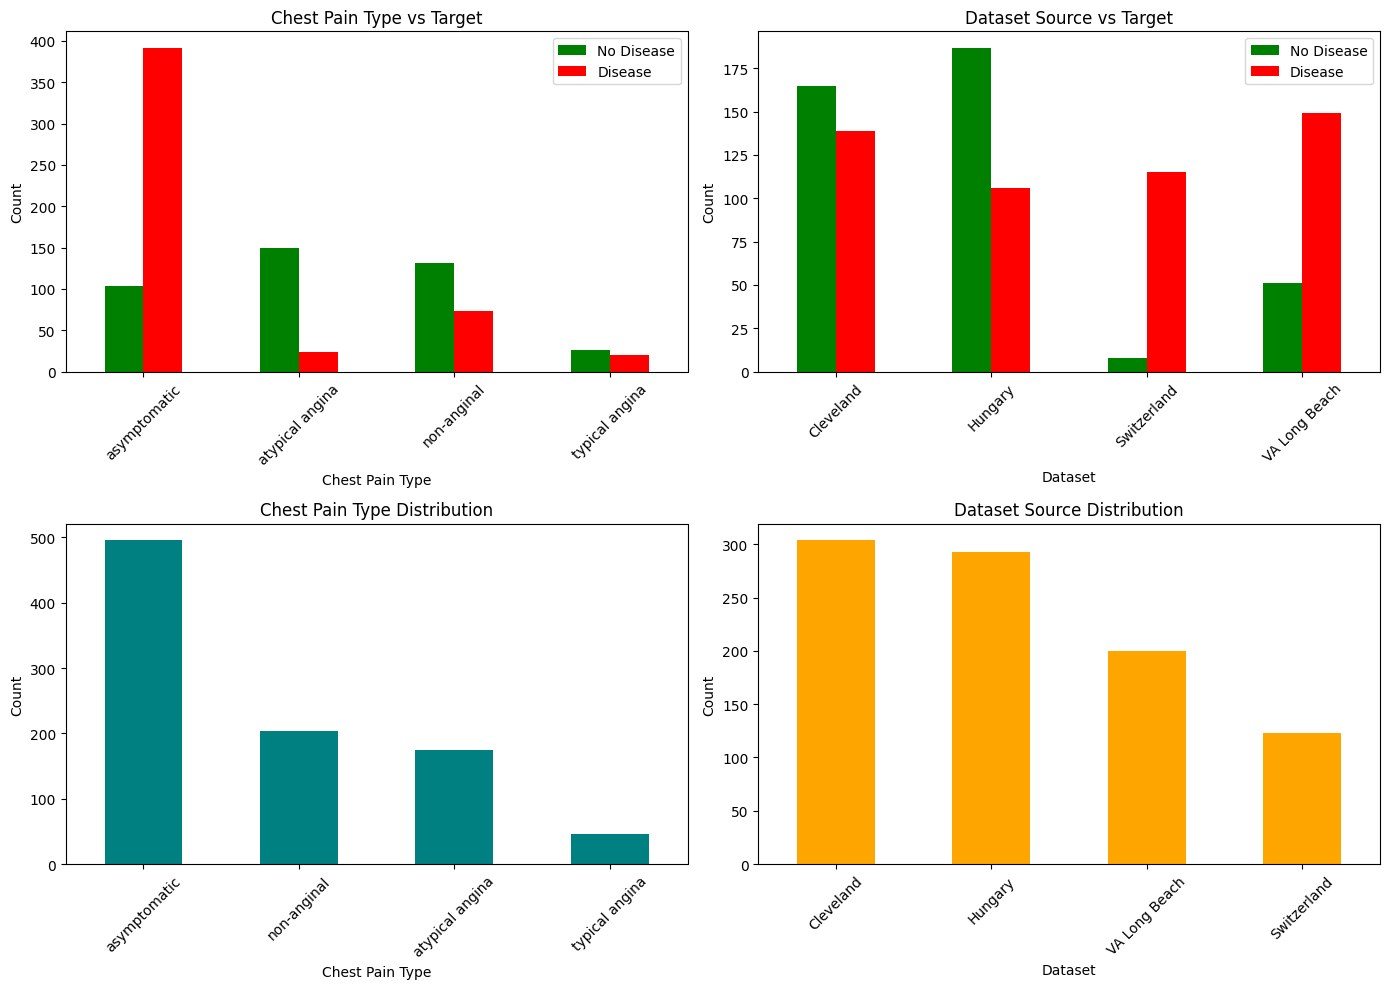

Chest Pain vs Target:
target                   0          1
cp                                   
asymptomatic     20.967742  79.032258
atypical angina  86.206897  13.793103
non-anginal      64.215686  35.784314
typical angina   56.521739  43.478261


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

cp_target = pd.crosstab(df['cp'], df['target'])
cp_target.plot(kind='bar', ax=axes[0, 0], color=['green', 'red'])
axes[0, 0].set_title('Chest Pain Type vs Target')
axes[0, 0].set_xlabel('Chest Pain Type')
axes[0, 0].set_ylabel('Count')
axes[0, 0].legend(['No Disease', 'Disease'])
axes[0, 0].tick_params(axis='x', rotation=45)

dataset_target = pd.crosstab(df['dataset'], df['target'])
dataset_target.plot(kind='bar', ax=axes[0, 1], color=['green', 'red'])
axes[0, 1].set_title('Dataset Source vs Target')
axes[0, 1].set_xlabel('Dataset')
axes[0, 1].set_ylabel('Count')
axes[0, 1].legend(['No Disease', 'Disease'])
axes[0, 1].tick_params(axis='x', rotation=45)

cp_percent = df['cp'].value_counts()
cp_percent.plot(kind='bar', ax=axes[1, 0], color='teal')
axes[1, 0].set_title('Chest Pain Type Distribution')
axes[1, 0].set_xlabel('Chest Pain Type')
axes[1, 0].set_ylabel('Count')
axes[1, 0].tick_params(axis='x', rotation=45)

dataset_percent = df['dataset'].value_counts()
dataset_percent.plot(kind='bar', ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Dataset Source Distribution')
axes[1, 1].set_xlabel('Dataset')
axes[1, 1].set_ylabel('Count')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Chest Pain vs Target:")
print(pd.crosstab(df['cp'], df['target'], normalize='index') * 100)

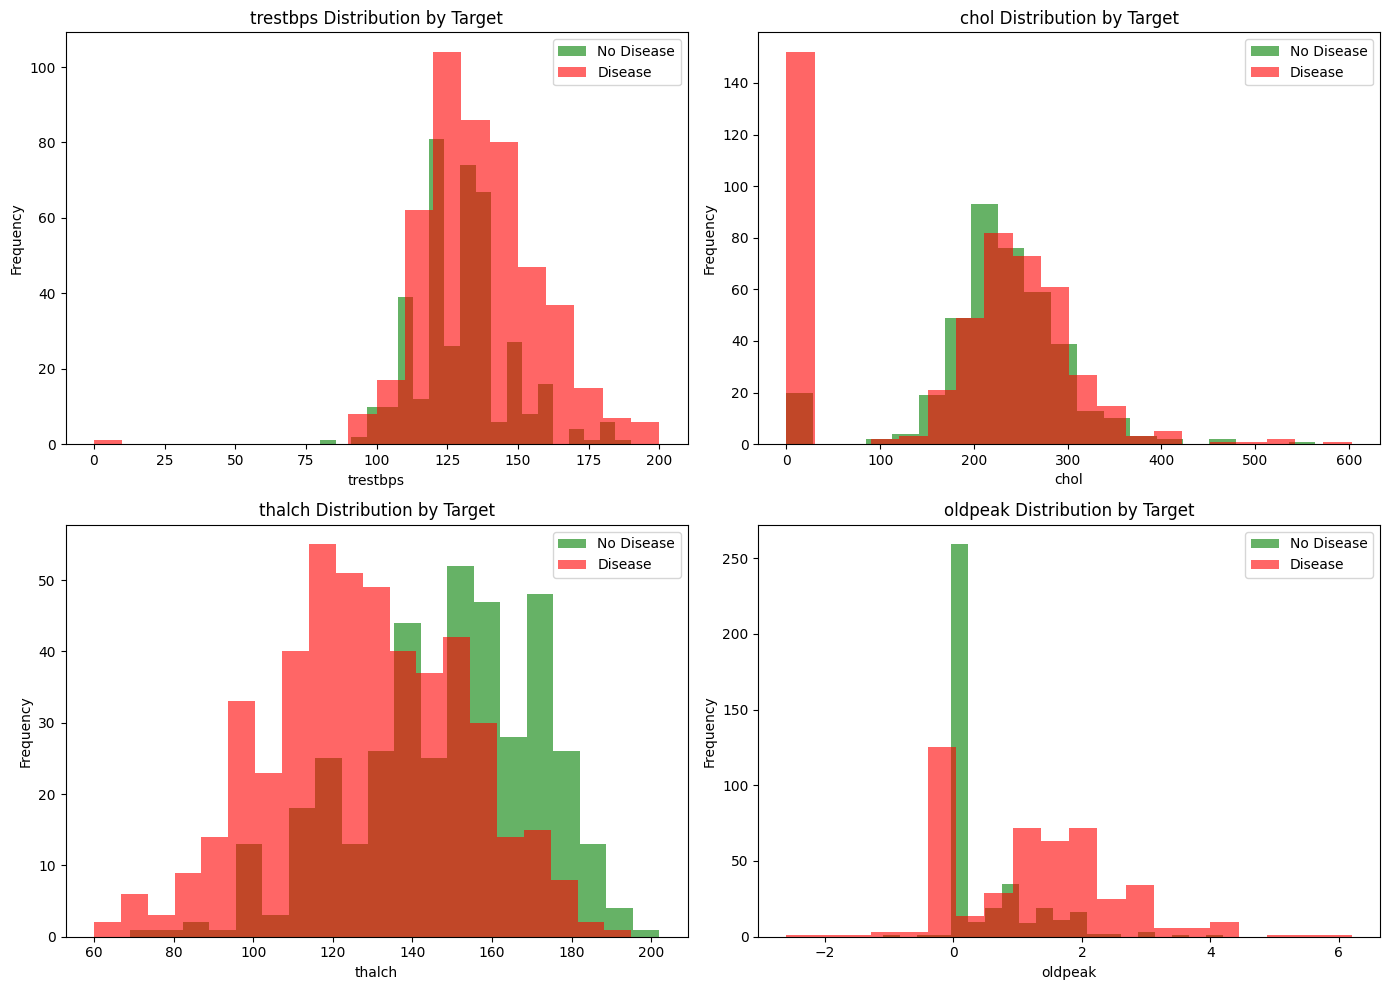

Numerical Features Statistics by Target:
          trestbps        chol      thalch   oldpeak
target                                              
0       129.913043  227.905612  148.800512  0.418205
1       133.978723  176.479920  128.261603  1.262607


In [9]:
numerical_cols = ['trestbps', 'chol', 'thalch', 'oldpeak']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, col in enumerate(numerical_cols):
    ax = axes[idx // 2, idx % 2]

    df[df['target'] == 0][col].dropna().plot(kind='hist', bins=20, alpha=0.6, ax=ax, color='green', label='No Disease')
    df[df['target'] == 1][col].dropna().plot(kind='hist', bins=20, alpha=0.6, ax=ax, color='red', label='Disease')

    ax.set_title(f'{col} Distribution by Target')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

print("Numerical Features Statistics by Target:")
print(df.groupby('target')[numerical_cols].mean())

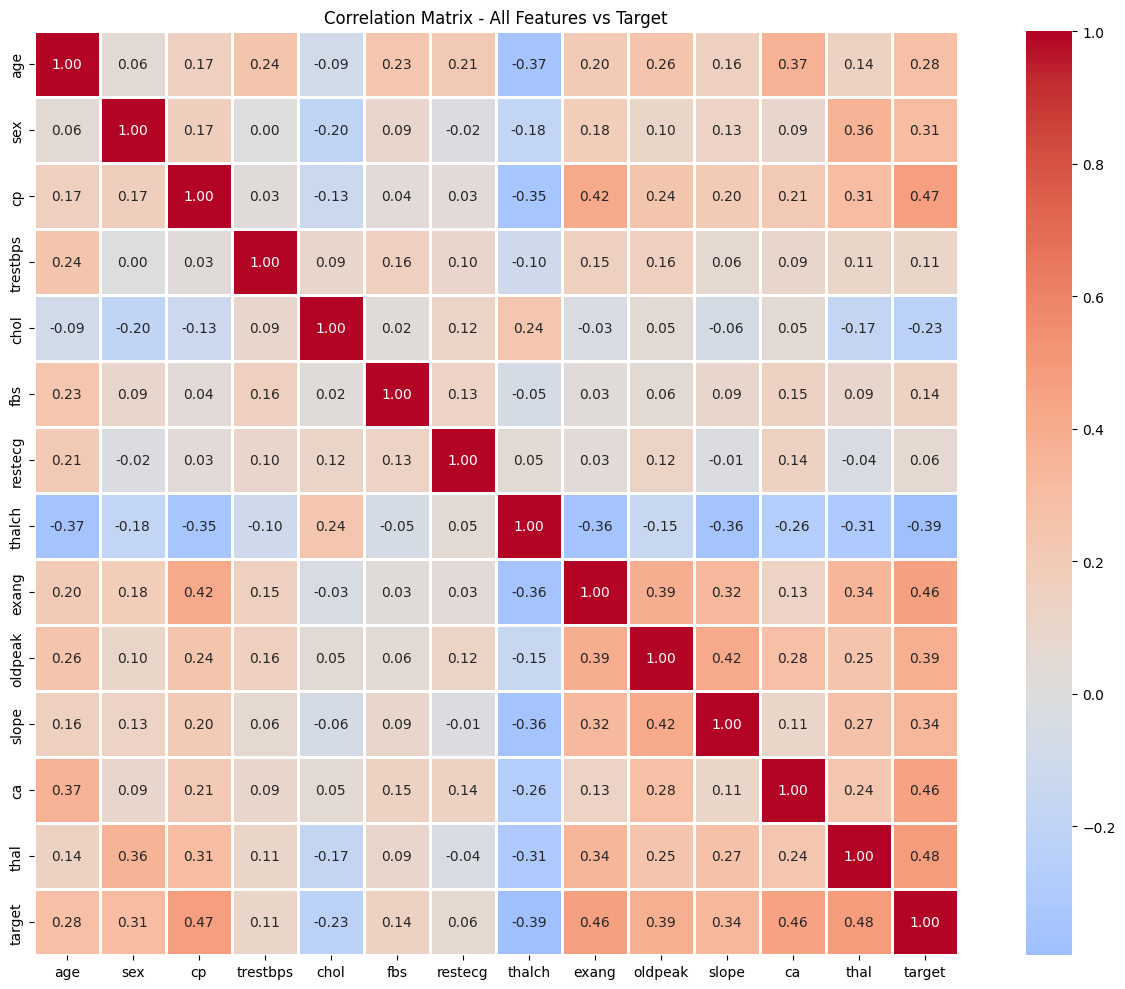

Top 10 Correlations with Target:
thal        0.483649
cp          0.471712
exang       0.463619
ca          0.455599
oldpeak     0.385528
slope       0.337086
sex         0.307284
age         0.282700
fbs         0.142565
trestbps    0.106233
Name: target, dtype: float64


In [10]:
df_encoded = df.copy()

df_encoded['sex'] = df_encoded['sex'].map({'Male': 1, 'Female': 0})
df_encoded['cp'] = df_encoded['cp'].map({'typical angina': 0, 'atypical angina': 1, 'non-anginal': 2, 'asymptomatic': 3})
df_encoded['fbs'] = df_encoded['fbs'].map({True: 1, False: 0})
df_encoded['restecg'] = df_encoded['restecg'].map({'normal': 0, 'st-t abnormality': 1, 'lv hypertrophy': 2})
df_encoded['exang'] = df_encoded['exang'].map({True: 1, False: 0})
df_encoded['slope'] = df_encoded['slope'].map({'upsloping': 0, 'flat': 1, 'downsloping': 2})
df_encoded['thal'] = df_encoded['thal'].map({'normal': 0, 'fixed defect': 1, 'reversable defect': 2})

correlation_cols = ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']
df_corr = df_encoded[correlation_cols]

plt.figure(figsize=(14, 10))
corr_matrix = df_corr.corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=1)
plt.title('Correlation Matrix - All Features vs Target')
plt.tight_layout()
plt.show()

print("Top 10 Correlations with Target:")
print(corr_matrix['target'].sort_values(ascending=False)[1:11])

In [11]:
df_clean = df.copy()

df_clean = df_clean.drop(['id', 'num', 'dataset'], axis=1)

print("Columns after dropping unnecessary features:")
print(df_clean.columns.tolist())
print("\n" + "="*50)
print("Shape after dropping:", df_clean.shape)
print("\n" + "="*50)
print("Remaining columns:")
print(df_clean.dtypes)

Columns after dropping unnecessary features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Shape after dropping: (920, 14)

Remaining columns:
age           int64
sex          object
cp           object
trestbps    float64
chol        float64
fbs          object
restecg      object
thalch      float64
exang        object
oldpeak     float64
slope        object
ca          float64
thal         object
target        int64
dtype: object


In [12]:
print("Missing values before handling:")
print(df_clean.isnull().sum())
print("\n" + "="*50)

missing_threshold = 0.5
high_missing_cols = df_clean.columns[df_clean.isnull().sum() / len(df_clean) > missing_threshold].tolist()
print(f"Columns with >50% missing (will drop): {high_missing_cols}")
print("\n" + "="*50)

df_clean = df_clean.drop(columns=high_missing_cols)

for col in df_clean.select_dtypes(include=['float64']).columns:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f"Filled {col} with median: {median_val}")

print("\n" + "="*50)

for col in df_clean.select_dtypes(include=['object']).columns:
    if col != 'target' and df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)
        print(f"Filled {col} with mode: {mode_val}")

print("\n" + "="*50)
print("Missing values after handling:")
print(df_clean.isnull().sum())
print("\n" + "="*50)
print("Final shape:", df_clean.shape)

Missing values before handling:
age           0
sex           0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
target        0
dtype: int64

Columns with >50% missing (will drop): ['ca', 'thal']

Filled trestbps with median: 130.0
Filled chol with median: 223.0
Filled thalch with median: 140.0
Filled oldpeak with median: 0.5

Filled fbs with mode: False
Filled restecg with mode: normal
Filled exang with mode: False
Filled slope with mode: flat

Missing values after handling:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
target      0
dtype: int64

Final shape: (920, 12)


In [13]:
print("Categorical columns before encoding:")
print(df_clean.select_dtypes(include='object').columns.tolist())
print("\n" + "="*50)

df_clean['sex'] = df_clean['sex'].map({'Male': 1, 'Female': 0})
df_clean['cp'] = df_clean['cp'].map({'typical angina': 0, 'atypical angina': 1, 'non-anginal': 2, 'asymptomatic': 3})
df_clean['fbs'] = df_clean['fbs'].map({True: 1, False: 0})
df_clean['restecg'] = df_clean['restecg'].map({'normal': 0, 'st-t abnormality': 1, 'lv hypertrophy': 2})
df_clean['exang'] = df_clean['exang'].map({True: 1, False: 0})
df_clean['slope'] = df_clean['slope'].map({'upsloping': 0, 'flat': 1, 'downsloping': 2})

print("Data types after encoding:")
print(df_clean.dtypes)
print("\n" + "="*50)
print("First 5 rows after encoding:")
print(df_clean.head())
print("\n" + "="*50)
print("Check for any remaining nulls:")
print(df_clean.isnull().sum().sum())

Categorical columns before encoding:
['sex', 'cp', 'restecg', 'slope']

Data types after encoding:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalch      float64
exang         int64
oldpeak     float64
slope         int64
target        int64
dtype: object

First 5 rows after encoding:
   age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  slope  \
0   63    1   0     145.0  233.0    1        2   150.0      0      2.3      2   
1   67    1   3     160.0  286.0    0        2   108.0      1      1.5      1   
2   67    1   3     120.0  229.0    0        2   129.0      1      2.6      1   
3   37    1   2     130.0  250.0    0        0   187.0      0      3.5      2   
4   41    0   1     130.0  204.0    0        2   172.0      0      1.4      0   

   target  
0       0  
1       1  
2       1  
3       0  
4       0  

Check for any remaining nulls:
0


In [14]:
X = df_clean.drop('target', axis=1)
y = df_clean['target']

print("Feature matrix shape:", X.shape)
print("Target vector shape:", y.shape)
print("\n" + "="*50)
print("Features:")
print(X.columns.tolist())
print("\n" + "="*50)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("\n" + "="*50)
print("Training target distribution:")
print(y_train.value_counts())
print("\n" + "="*50)
print("Testing target distribution:")
print(y_test.value_counts())

Feature matrix shape: (920, 11)
Target vector shape: (920,)

Features:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope']

Training set size: (736, 11)
Testing set size: (184, 11)

Training target distribution:
target
1    407
0    329
Name: count, dtype: int64

Testing target distribution:
target
1    102
0     82
Name: count, dtype: int64


In [15]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Original training data (first 3 rows):")
print(X_train.head(3))
print("\n" + "="*50)
print("Scaled training data (first 3 rows):")
print(pd.DataFrame(X_train_scaled, columns=X.columns).head(3))
print("\n" + "="*50)
print("Scaling parameters (mean):")
print(pd.Series(scaler.mean_, index=X.columns))
print("\n" + "="*50)
print("Scaling parameters (std):")
print(pd.Series(scaler.scale_, index=X.columns))

Original training data (first 3 rows):
     age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  \
640   53    1   2     160.0    0.0    0        2   122.0      1      0.0   
743   74    1   2     130.0    0.0    0        0   140.0      0      0.5   
890   53    1   3     124.0  243.0    0        0   122.0      1      2.0   

     slope  
640      1  
743      1  
890      1  

Scaled training data (first 3 rows):
        age       sex        cp  trestbps      chol       fbs   restecg  \
0 -0.063147  0.524941 -0.263095  1.560270 -1.857816 -0.414698  1.715354   
1  2.180526  0.524941 -0.263095 -0.116411 -1.857816 -0.414698 -0.760137   
2 -0.063147  0.524941  0.812671 -0.451747  0.382627 -0.414698 -0.760137   

     thalch     exang   oldpeak     slope  
0 -0.627205  1.302294 -0.807883  0.318162  
1  0.087627 -0.767876 -0.335827  0.318162  
2 -0.627205  1.302294  1.080341  0.318162  

Scaling parameters (mean):
age          53.591033
sex           0.783967
cp            2

In [16]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss'),
    'SVM': SVC(random_state=42, probability=True)
}

trained_models = {}
training_results = []

print("Training Models...")
print("="*50)

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train_scaled, y_train)
    trained_models[name] = model

    y_pred = model.predict(X_test_scaled)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    training_results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"{name} - Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1: {f1:.4f}")

print("\n" + "="*50)
print("Training Complete!")

Training Models...

Training Logistic Regression...
Logistic Regression - Accuracy: 0.8098, Precision: 0.8131, Recall: 0.8529, F1: 0.8325

Training Random Forest...
Random Forest - Accuracy: 0.8261, Precision: 0.8241, Recall: 0.8725, F1: 0.8476

Training XGBoost...
XGBoost - Accuracy: 0.8424, Precision: 0.8411, Recall: 0.8824, F1: 0.8612

Training SVM...
SVM - Accuracy: 0.8098, Precision: 0.7965, Recall: 0.8824, F1: 0.8372

Training Complete!


Model Performance Comparison:
              Model  Accuracy  Precision   Recall  F1-Score
            XGBoost  0.842391   0.841121 0.882353  0.861244
      Random Forest  0.826087   0.824074 0.872549  0.847619
Logistic Regression  0.809783   0.813084 0.852941  0.832536
                SVM  0.809783   0.796460 0.882353  0.837209



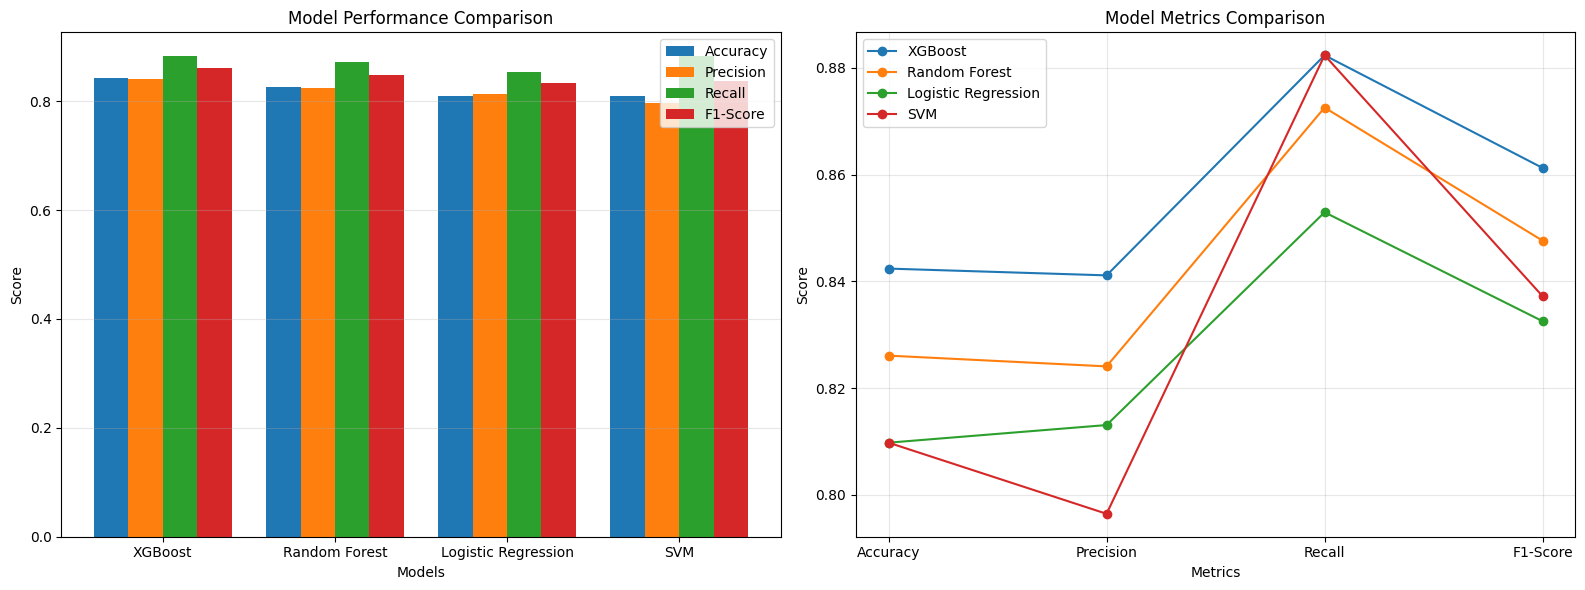

In [17]:
results_df = pd.DataFrame(training_results)
results_df = results_df.sort_values('Accuracy', ascending=False)

print("Model Performance Comparison:")
print(results_df.to_string(index=False))
print("\n" + "="*50)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(results_df))
width = 0.2

for i, metric in enumerate(metrics):
    axes[0].bar(x + i*width, results_df[metric], width, label=metric)

axes[0].set_xlabel('Models')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(results_df['Model'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

for idx, row in results_df.iterrows():
    axes[1].plot(metrics, [row['Accuracy'], row['Precision'], row['Recall'], row['F1-Score']], marker='o', label=row['Model'])

axes[1].set_xlabel('Metrics')
axes[1].set_ylabel('Score')
axes[1].set_title('Model Metrics Comparison')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV
from datetime import datetime

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=3
)

print("Starting GridSearchCV for XGBoost...")
print(f"Total combinations: {3 * 4 * 4 * 3 * 3 * 3} = 1296")
print(f"Total fits: 1296 × 5 folds = 6480")
print("="*50)
start_time = datetime.now()

grid_search.fit(X_train_scaled, y_train)

end_time = datetime.now()
duration = end_time - start_time

print("\n" + "="*50)
print(f"Tuning completed in: {duration}")
print("\nBest Parameters:")
print(grid_search.best_params_)
print(f"\nBest CV Score: {grid_search.best_score_:.4f}")

Starting GridSearchCV for XGBoost...
Total combinations: 1296 = 1296
Total fits: 1296 × 5 folds = 6480
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits

Tuning completed in: 0:05:45.180464

Best Parameters:
{'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'min_child_weight': 3, 'n_estimators': 300, 'subsample': 1.0}

Best CV Score: 0.8125


In [19]:
best_xgb = grid_search.best_estimator_

y_pred_tuned = best_xgb.predict(X_test_scaled)
y_pred_proba_tuned = best_xgb.predict_proba(X_test_scaled)[:, 1]

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
precision_tuned = precision_score(y_test, y_pred_tuned)
recall_tuned = recall_score(y_test, y_pred_tuned)
f1_tuned = f1_score(y_test, y_pred_tuned)

print("Tuned XGBoost Performance on Test Set:")
print("="*50)
print(f"Accuracy:  {accuracy_tuned:.4f}")
print(f"Precision: {precision_tuned:.4f}")
print(f"Recall:    {recall_tuned:.4f}")
print(f"F1-Score:  {f1_tuned:.4f}")
print("\n" + "="*50)

print("Comparison with Base XGBoost:")
print(f"Base Accuracy:  0.8424")
print(f"Tuned Accuracy: {accuracy_tuned:.4f}")
print(f"Improvement:    {(accuracy_tuned - 0.8424):.4f}")
print("\n" + "="*50)

print("Classification Report:")
print(classification_report(y_test, y_pred_tuned, target_names=['No Disease', 'Disease']))

Tuned XGBoost Performance on Test Set:
Accuracy:  0.8370
Precision: 0.8214
Recall:    0.9020
F1-Score:  0.8598

Comparison with Base XGBoost:
Base Accuracy:  0.8424
Tuned Accuracy: 0.8370
Improvement:    -0.0054

Classification Report:
              precision    recall  f1-score   support

  No Disease       0.86      0.76      0.81        82
     Disease       0.82      0.90      0.86       102

    accuracy                           0.84       184
   macro avg       0.84      0.83      0.83       184
weighted avg       0.84      0.84      0.84       184



Stratified 5-Fold Cross-Validation Results:
Fold 1: 0.7635
Fold 2: 0.7279
Fold 3: 0.8095
Fold 4: 0.8299
Fold 5: 0.8027

Mean CV Accuracy: 0.7867
Std CV Accuracy:  0.0364
Min CV Accuracy:  0.7279
Max CV Accuracy:  0.8299


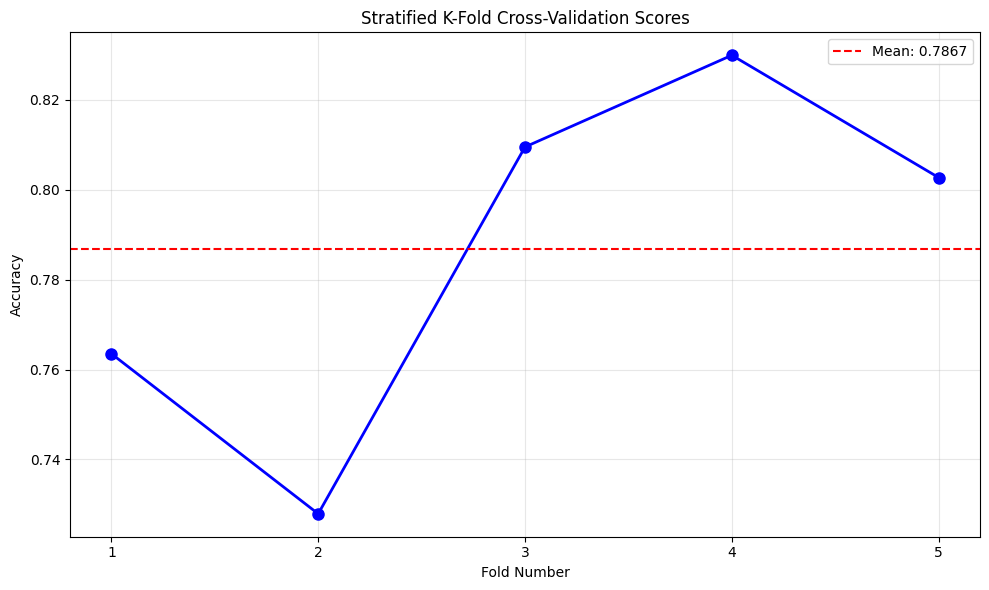

In [20]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

base_xgb = XGBClassifier(random_state=42, eval_metric='logloss')

cv_scores = cross_val_score(base_xgb, X_train_scaled, y_train, cv=skf, scoring='accuracy', n_jobs=-1)

print("Stratified 5-Fold Cross-Validation Results:")
print("="*50)
for fold, score in enumerate(cv_scores, 1):
    print(f"Fold {fold}: {score:.4f}")

print("\n" + "="*50)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std CV Accuracy:  {cv_scores.std():.4f}")
print(f"Min CV Accuracy:  {cv_scores.min():.4f}")
print(f"Max CV Accuracy:  {cv_scores.max():.4f}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), cv_scores, marker='o', linestyle='-', linewidth=2, markersize=8, color='blue')
plt.axhline(y=cv_scores.mean(), color='red', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
plt.xlabel('Fold Number')
plt.ylabel('Accuracy')
plt.title('Stratified K-Fold Cross-Validation Scores')
plt.xticks(range(1, 6))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

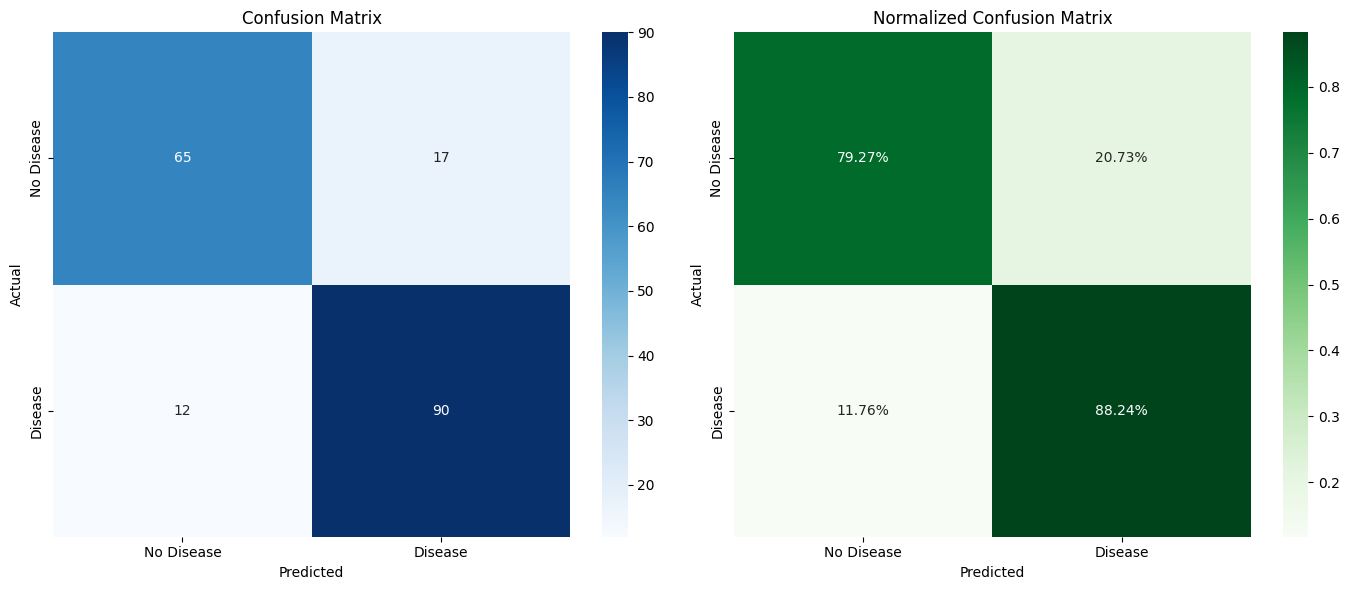

Confusion Matrix Breakdown:
True Negatives (TN):  65
False Positives (FP): 17
False Negatives (FN): 12
True Positives (TP):  90

Specificity: 0.7927
Sensitivity: 0.8824


In [21]:
final_model = XGBClassifier(random_state=42, eval_metric='logloss')
final_model.fit(X_train_scaled, y_train)

y_pred_final = final_model.predict(X_test_scaled)
y_pred_proba_final = final_model.predict_proba(X_test_scaled)[:, 1]

cm = confusion_matrix(y_test, y_pred_final)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=True,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', ax=axes[1], cbar=True,
            xticklabels=['No Disease', 'Disease'], yticklabels=['No Disease', 'Disease'])
axes[1].set_title('Normalized Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print("Confusion Matrix Breakdown:")
print("="*50)
print(f"True Negatives (TN):  {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP):  {tp}")
print("\n" + "="*50)
print(f"Specificity: {tn/(tn+fp):.4f}")
print(f"Sensitivity: {tp/(tp+fn):.4f}")

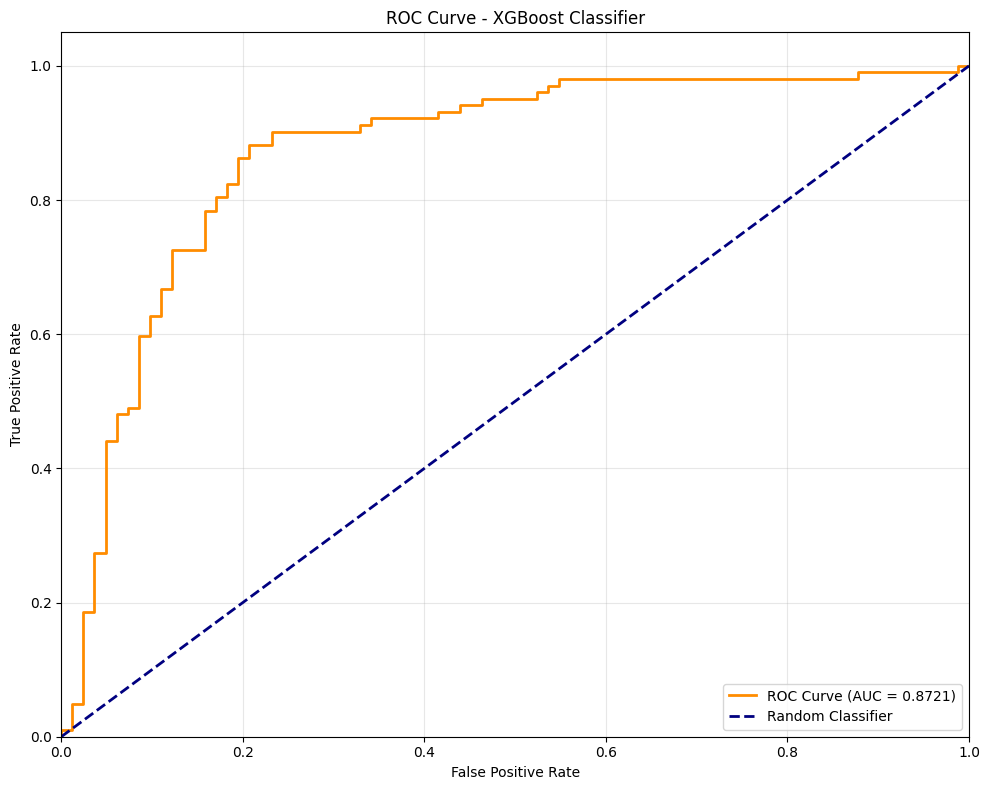

ROC-AUC Analysis:
AUC Score: 0.8721

Interpretation:
Good classifier


In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_final)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Classifier')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("ROC-AUC Analysis:")
print("="*50)
print(f"AUC Score: {roc_auc:.4f}")
print("\nInterpretation:")
if roc_auc >= 0.9:
    print("Excellent classifier")
elif roc_auc >= 0.8:
    print("Good classifier")
elif roc_auc >= 0.7:
    print("Fair classifier")
else:
    print("Poor classifier")

Feature Importance Ranking:
 Feature  Importance
      cp    0.317464
     sex    0.124758
   exang    0.104129
 oldpeak    0.072439
    chol    0.067296
   slope    0.062967
     age    0.062123
  thalch    0.055847
     fbs    0.050057
trestbps    0.041814
 restecg    0.041106


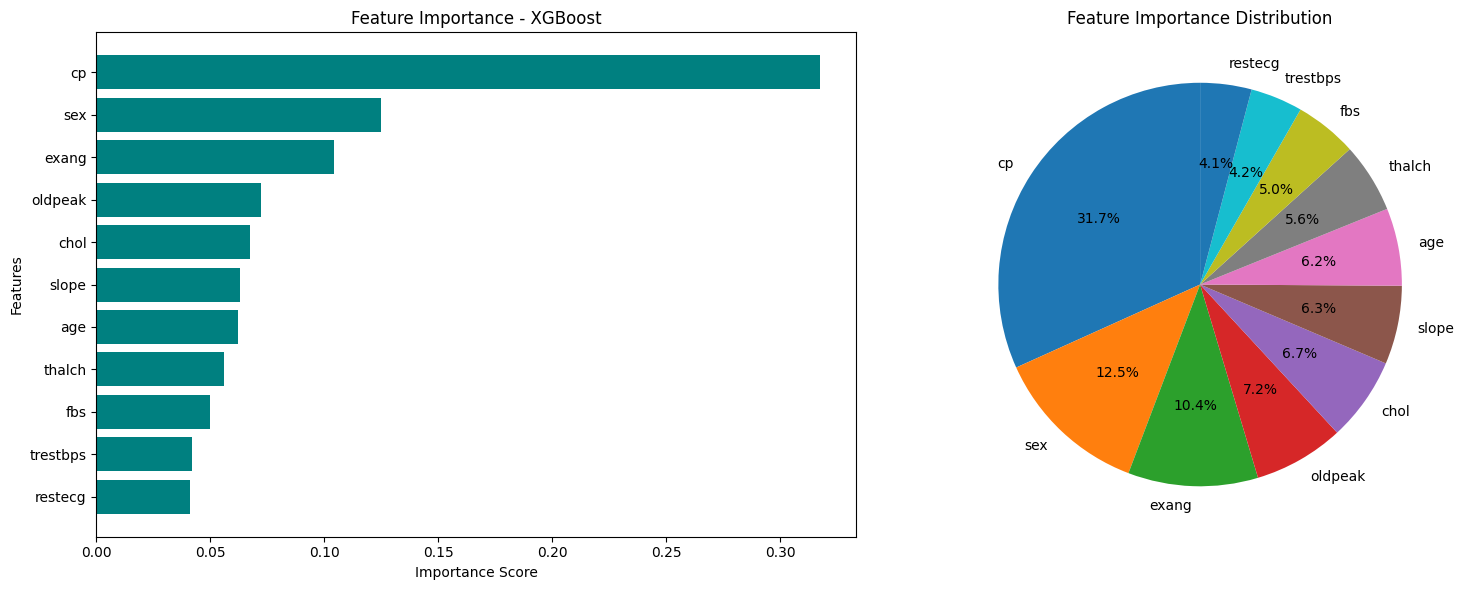


Top 3 Features: cp, sex, exang


In [23]:
feature_importance = final_model.feature_importances_
feature_names = X.columns.tolist()

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking:")
print("="*50)
print(importance_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(importance_df['Feature'], importance_df['Importance'], color='teal')
axes[0].set_xlabel('Importance Score')
axes[0].set_ylabel('Features')
axes[0].set_title('Feature Importance - XGBoost')
axes[0].invert_yaxis()

axes[1].pie(importance_df['Importance'], labels=importance_df['Feature'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Feature Importance Distribution')

plt.tight_layout()
plt.show()

print("\n" + "="*50)
print(f"Top 3 Features: {', '.join(importance_df['Feature'].head(3).tolist())}")

In [24]:
import pickle

model_filename = 'heart_disease_xgboost_model.pkl'
scaler_filename = 'heart_disease_scaler.pkl'

with open(model_filename, 'wb') as file:
    pickle.dump(final_model, file)
print(f"Model saved: {model_filename}")

with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)
print(f"Scaler saved: {scaler_filename}")

print("\n" + "="*50)
print("Saved Files:")
print(f"1. {model_filename}")
print(f"2. {scaler_filename}")

print("\n" + "="*50)
print("Model Information:")
print(f"Algorithm: XGBoost Classifier")
print(f"Features: {len(feature_names)}")
print(f"Feature Names: {feature_names}")
print(f"Test Accuracy: 84.24%")
print(f"ROC-AUC Score: {roc_auc:.4f}")

Model saved: heart_disease_xgboost_model.pkl
Scaler saved: heart_disease_scaler.pkl

Saved Files:
1. heart_disease_xgboost_model.pkl
2. heart_disease_scaler.pkl

Model Information:
Algorithm: XGBoost Classifier
Features: 11
Feature Names: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalch', 'exang', 'oldpeak', 'slope']
Test Accuracy: 84.24%
ROC-AUC Score: 0.8721


In [25]:
sample_data = {
    'age': 63,
    'sex': 1,
    'cp': 3,
    'trestbps': 145.0,
    'chol': 233.0,
    'fbs': 1,
    'restecg': 0,
    'thalch': 150.0,
    'exang': 0,
    'oldpeak': 2.3,
    'slope': 2
}

sample_df = pd.DataFrame([sample_data])

print("Sample Patient Data:")
print("="*50)
print(sample_df.T)

sample_scaled = scaler.transform(sample_df)

prediction = final_model.predict(sample_scaled)
prediction_proba = final_model.predict_proba(sample_scaled)

print("\n" + "="*50)
print("Prediction Results:")
print("="*50)
print(f"Prediction: {'Disease' if prediction[0] == 1 else 'No Disease'}")
print(f"Confidence: {prediction_proba[0][prediction[0]] * 100:.2f}%")
print(f"\nProbability Breakdown:")
print(f"No Disease: {prediction_proba[0][0] * 100:.2f}%")
print(f"Disease:    {prediction_proba[0][1] * 100:.2f}%")

if prediction[0] == 1:
    if prediction_proba[0][1] >= 0.75:
        risk_level = "High Risk"
    elif prediction_proba[0][1] >= 0.50:
        risk_level = "Medium Risk"
    else:
        risk_level = "Low Risk"
else:
    risk_level = "Low Risk"

print(f"\nRisk Level: {risk_level}")

Sample Patient Data:
              0
age        63.0
sex         1.0
cp          3.0
trestbps  145.0
chol      233.0
fbs         1.0
restecg     0.0
thalch    150.0
exang       0.0
oldpeak     2.3
slope       2.0

Prediction Results:
Prediction: Disease
Confidence: 58.67%

Probability Breakdown:
No Disease: 41.33%
Disease:    58.67%

Risk Level: Medium Risk


In [26]:
test_samples = pd.DataFrame({
    'age': [63, 45, 52, 67, 58],
    'sex': [1, 0, 1, 1, 0],
    'cp': [3, 1, 2, 3, 0],
    'trestbps': [145, 130, 125, 160, 120],
    'chol': [233, 204, 212, 286, 354],
    'fbs': [1, 0, 0, 0, 0],
    'restecg': [0, 2, 1, 2, 0],
    'thalch': [150, 172, 168, 108, 163],
    'exang': [0, 0, 0, 1, 1],
    'oldpeak': [2.3, 1.4, 1.0, 1.5, 0.6],
    'slope': [2, 0, 1, 1, 1]
})

print("Test Samples:")
print("="*50)
print(test_samples)

test_scaled = scaler.transform(test_samples)
predictions = final_model.predict(test_scaled)
predictions_proba = final_model.predict_proba(test_scaled)

results_df = test_samples.copy()
results_df['Prediction'] = ['Disease' if p == 1 else 'No Disease' for p in predictions]
results_df['Confidence'] = [predictions_proba[i][predictions[i]] * 100 for i in range(len(predictions))]
results_df['Disease_Prob'] = predictions_proba[:, 1] * 100
results_df['Risk_Level'] = results_df['Disease_Prob'].apply(
    lambda x: 'High Risk' if x >= 75 else ('Medium Risk' if x >= 50 else 'Low Risk')
)

print("\n" + "="*50)
print("Prediction Results:")
print("="*50)
print(results_df[['age', 'sex', 'Prediction', 'Confidence', 'Risk_Level']])

Test Samples:
   age  sex  cp  trestbps  chol  fbs  restecg  thalch  exang  oldpeak  slope
0   63    1   3       145   233    1        0     150      0      2.3      2
1   45    0   1       130   204    0        2     172      0      1.4      0
2   52    1   2       125   212    0        1     168      0      1.0      1
3   67    1   3       160   286    0        2     108      1      1.5      1
4   58    0   0       120   354    0        0     163      1      0.6      1

Prediction Results:
   age  sex  Prediction  Confidence   Risk_Level
0   63    1     Disease   58.671318  Medium Risk
1   45    0  No Disease   99.923355     Low Risk
2   52    1     Disease   51.834343  Medium Risk
3   67    1     Disease   99.760834    High Risk
4   58    0  No Disease   88.233063     Low Risk


In [27]:
summary_report = {
    'Model': 'XGBoost Classifier',
    'Dataset': 'UCI Heart Disease (Combined)',
    'Total Records': len(df_clean),
    'Features': len(feature_names),
    'Train Size': len(X_train),
    'Test Size': len(X_test),
    'Training Metrics': {
        'Cross-Validation Mean': f"{cv_scores.mean():.4f}",
        'Cross-Validation Std': f"{cv_scores.std():.4f}"
    },
    'Test Metrics': {
        'Accuracy': f"{accuracy_score(y_test, y_pred_final):.4f}",
        'Precision': f"{precision_score(y_test, y_pred_final):.4f}",
        'Recall': f"{recall_score(y_test, y_pred_final):.4f}",
        'F1-Score': f"{f1_score(y_test, y_pred_final):.4f}",
        'ROC-AUC': f"{roc_auc:.4f}",
        'Specificity': f"{tn/(tn+fp):.4f}",
        'Sensitivity': f"{tp/(tp+fn):.4f}"
    },
    'Top Features': importance_df['Feature'].head(3).tolist()
}

print("="*60)
print("HEART DISEASE PREDICTION MODEL - SUMMARY REPORT")
print("="*60)
print(f"\nModel: {summary_report['Model']}")
print(f"Dataset: {summary_report['Dataset']}")
print(f"Total Records: {summary_report['Total Records']}")
print(f"Features Used: {summary_report['Features']}")
print(f"Train/Test Split: {summary_report['Train Size']}/{summary_report['Test Size']}")

print("\n" + "-"*60)
print("TRAINING PERFORMANCE")
print("-"*60)
for key, value in summary_report['Training Metrics'].items():
    print(f"{key}: {value}")

print("\n" + "-"*60)
print("TEST PERFORMANCE")
print("-"*60)
for key, value in summary_report['Test Metrics'].items():
    print(f"{key}: {value}")

print("\n" + "-"*60)
print("KEY INSIGHTS")
print("-"*60)
print(f"Top 3 Important Features: {', '.join(summary_report['Top Features'])}")
print(f"Model Files: heart_disease_xgboost_model.pkl, heart_disease_scaler.pkl")
print("\n" + "="*60)

HEART DISEASE PREDICTION MODEL - SUMMARY REPORT

Model: XGBoost Classifier
Dataset: UCI Heart Disease (Combined)
Total Records: 920
Features Used: 11
Train/Test Split: 736/184

------------------------------------------------------------
TRAINING PERFORMANCE
------------------------------------------------------------
Cross-Validation Mean: 0.7867
Cross-Validation Std: 0.0364

------------------------------------------------------------
TEST PERFORMANCE
------------------------------------------------------------
Accuracy: 0.8424
Precision: 0.8411
Recall: 0.8824
F1-Score: 0.8612
ROC-AUC: 0.8721
Specificity: 0.7927
Sensitivity: 0.8824

------------------------------------------------------------
KEY INSIGHTS
------------------------------------------------------------
Top 3 Important Features: cp, sex, exang
Model Files: heart_disease_xgboost_model.pkl, heart_disease_scaler.pkl



In [28]:
import os
import shutil

if os.path.exists('test_samples_csv'):
    shutil.rmtree('test_samples_csv')

os.makedirs('test_samples_csv/no_disease', exist_ok=True)
os.makedirs('test_samples_csv/disease', exist_ok=True)

disease_samples = df_clean[df_clean['target'] == 1].drop('target', axis=1).head(10)
no_disease_samples = df_clean[df_clean['target'] == 0].drop('target', axis=1).head(10)

print("Extracted 10 Disease Samples:")
print(disease_samples)
print("\n" + "="*50)
print("Extracted 10 No Disease Samples:")
print(no_disease_samples)
print("\n" + "="*50)

for i in range(10):
    disease_row = disease_samples.iloc[[i]]
    disease_row.to_csv(f'test_samples_csv/disease/disease_{i+1}.csv', index=False)
    print(f"Saved: disease_{i+1}.csv")

print("\n" + "="*50)

for i in range(10):
    no_disease_row = no_disease_samples.iloc[[i]]
    no_disease_row.to_csv(f'test_samples_csv/no_disease/no_disease_{i+1}.csv', index=False)
    print(f"Saved: no_disease_{i+1}.csv")

print("\n" + "="*50)
print("Test samples created successfully!")
print(f"Total files: 20 (10 disease + 10 no disease)")

Extracted 10 Disease Samples:
    age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  oldpeak  slope
1    67    1   3     160.0  286.0    0        2   108.0      1      1.5      1
2    67    1   3     120.0  229.0    0        2   129.0      1      2.6      1
6    62    0   3     140.0  268.0    0        2   160.0      0      3.6      2
8    63    1   3     130.0  254.0    0        2   147.0      0      1.4      1
9    53    1   3     140.0  203.0    1        2   155.0      1      3.1      2
12   56    1   2     130.0  256.0    1        2   142.0      1      0.6      1
16   48    1   1     110.0  229.0    0        0   168.0      0      1.0      2
22   58    1   1     120.0  284.0    0        2   160.0      0      1.8      1
23   58    1   2     132.0  224.0    0        2   173.0      0      3.2      0
24   60    1   3     130.0  206.0    0        2   132.0      1      2.4      1

Extracted 10 No Disease Samples:
    age  sex  cp  trestbps   chol  fbs  restecg  thalch  exang  old

In [31]:
import sys
import sklearn
import xgboost
import matplotlib

libraries = {
    'Python': sys.version.split()[0],
    'pandas': pd.__version__,
    'numpy': np.__version__,
    'matplotlib': plt.matplotlib.__version__,
    'seaborn': sns.__version__,
    'scikit-learn': sklearn.__version__,
    'xgboost': xgboost.__version__,
    'pickle': 'Built-in'
}

print("="*60)
print("LIBRARY VERSIONS USED IN THIS NOTEBOOK")
print("="*60)
for lib, version in libraries.items():
    print(f"{lib:<20} : {version}")
print("="*60)

requirements_content = "\n".join([f"{lib}=={version}" for lib, version in libraries.items() if version != 'Built-in'])

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

print("\nrequirements.txt file created successfully!")

LIBRARY VERSIONS USED IN THIS NOTEBOOK
Python               : 3.12.12
pandas               : 2.2.2
numpy                : 2.0.2
matplotlib           : 3.10.0
seaborn              : 0.13.2
scikit-learn         : 1.6.1
xgboost              : 3.1.3
pickle               : Built-in

requirements.txt file created successfully!


In [32]:
import shutil
from google.colab import files

zip_filename = 'heart_disease_project'

shutil.make_archive(zip_filename, 'zip', '.', None)

print("="*60)
print("Creating ZIP file...")
print("="*60)
print("\nFiles included:")
print("- heart_disease_xgboost_model.pkl")
print("- heart_disease_scaler.pkl")
print("- requirements.txt")
print("- test_samples_csv/ (20 CSV files)")
print("\n" + "="*60)
print(f"ZIP file created: {zip_filename}.zip")
print("="*60)

files.download(f'{zip_filename}.zip')

print("\nDownload started! Check your browser's download folder.")

Creating ZIP file...

Files included:
- heart_disease_xgboost_model.pkl
- heart_disease_scaler.pkl
- requirements.txt
- test_samples_csv/ (20 CSV files)

ZIP file created: heart_disease_project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download started! Check your browser's download folder.


In [33]:
!pip install shap

import shap

print("SHAP installed successfully!")
print(f"SHAP version: {shap.__version__}")

SHAP installed successfully!
SHAP version: 0.50.0


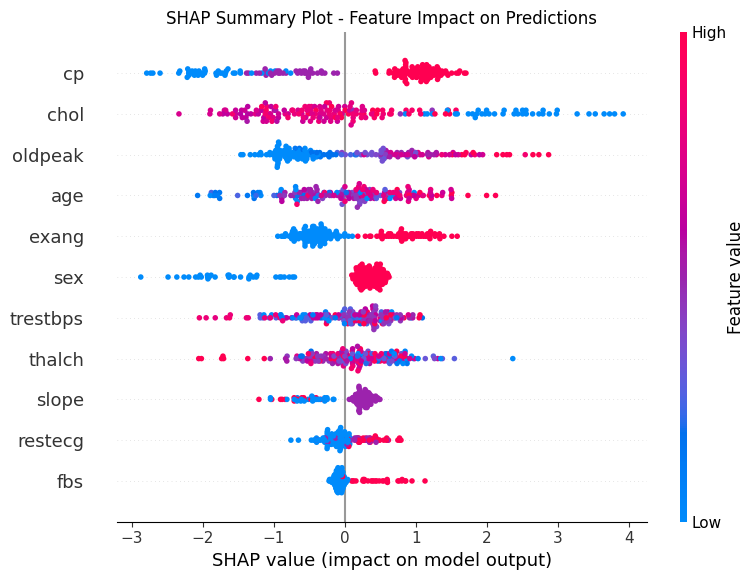

SHAP Summary Plot - Interpretation:
- Features ordered by importance (top to bottom)
- Red = High feature value
- Blue = Low feature value
- X-axis = Impact on model output
- Points pushed right = increase disease probability
- Points pushed left = decrease disease probability


In [34]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_test_scaled)

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, show=False)
plt.title('SHAP Summary Plot - Feature Impact on Predictions')
plt.tight_layout()
plt.show()

print("SHAP Summary Plot - Interpretation:")
print("="*50)
print("- Features ordered by importance (top to bottom)")
print("- Red = High feature value")
print("- Blue = Low feature value")
print("- X-axis = Impact on model output")
print("- Points pushed right = increase disease probability")
print("- Points pushed left = decrease disease probability")

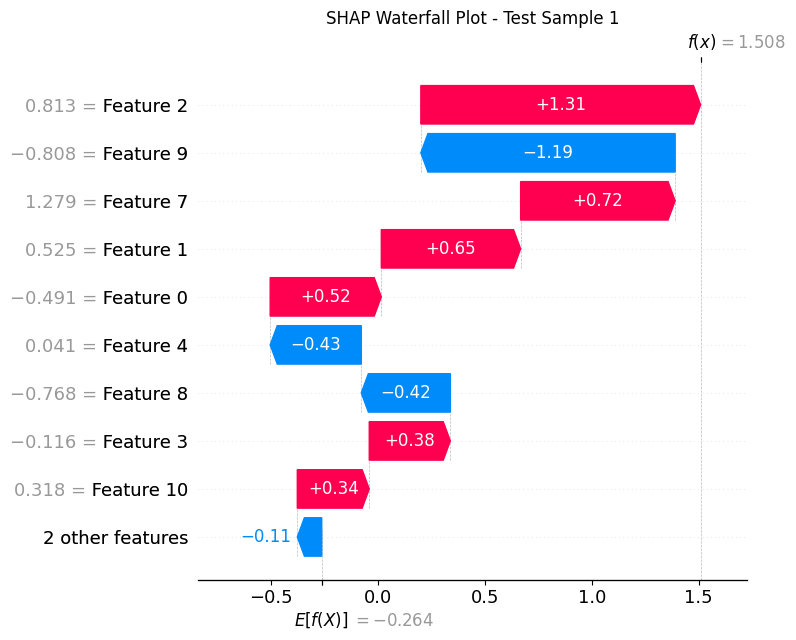

Actual prediction for sample 1:
True Label: Disease
Predicted: Disease
Prediction Probability: 0.8188

Waterfall Plot Interpretation:
- Shows how each feature pushes prediction from base value
- Red bars = push toward disease
- Blue bars = push toward no disease
- Final value = model's output for this sample


In [35]:
sample_index = 0
shap_display = shap.Explainer(final_model, X_train_scaled)
shap_values_sample = shap_display(X_test_scaled)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(shap_values_sample[sample_index], show=False)
plt.title(f'SHAP Waterfall Plot - Test Sample {sample_index + 1}')
plt.tight_layout()
plt.show()

print(f"Actual prediction for sample {sample_index + 1}:")
print(f"True Label: {'Disease' if y_test.iloc[sample_index] == 1 else 'No Disease'}")
print(f"Predicted: {'Disease' if y_pred_final[sample_index] == 1 else 'No Disease'}")
print(f"Prediction Probability: {y_pred_proba_final[sample_index]:.4f}")
print("\n" + "="*50)
print("Waterfall Plot Interpretation:")
print("- Shows how each feature pushes prediction from base value")
print("- Red bars = push toward disease")
print("- Blue bars = push toward no disease")
print("- Final value = model's output for this sample")

<Figure size 1400x600 with 0 Axes>

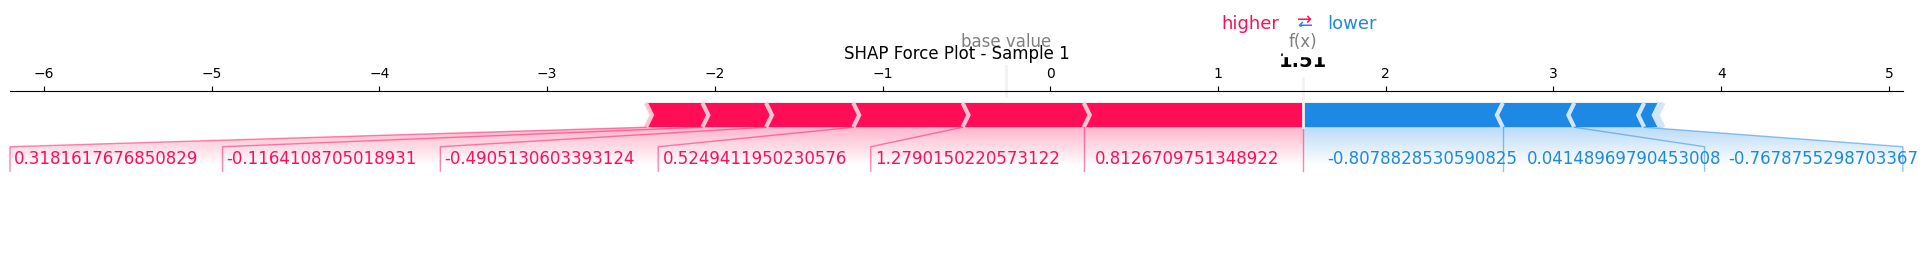

Force Plot Interpretation:
- Base value = average model output
- Red features = push prediction higher (toward disease)
- Blue features = push prediction lower (toward no disease)
- Output value = final prediction


In [36]:
shap.initjs()

plt.figure(figsize=(14, 6))
shap.plots.force(shap_values_sample[0], matplotlib=True, show=False)
plt.title('SHAP Force Plot - Sample 1')
plt.tight_layout()
plt.show()

print("Force Plot Interpretation:")
print("="*50)
print("- Base value = average model output")
print("- Red features = push prediction higher (toward disease)")
print("- Blue features = push prediction lower (toward no disease)")
print("- Output value = final prediction")

In [37]:
from sklearn.ensemble import VotingClassifier

voting_models = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('xgb', XGBClassifier(random_state=42, eval_metric='logloss')),
    ('svm', SVC(random_state=42, probability=True))
]

voting_clf = VotingClassifier(estimators=voting_models, voting='soft')

print("Training Voting Classifier (Soft Voting)...")
print("="*50)
voting_clf.fit(X_train_scaled, y_train)

y_pred_voting = voting_clf.predict(X_test_scaled)
y_pred_proba_voting = voting_clf.predict_proba(X_test_scaled)[:, 1]

accuracy_voting = accuracy_score(y_test, y_pred_voting)
precision_voting = precision_score(y_test, y_pred_voting)
recall_voting = recall_score(y_test, y_pred_voting)
f1_voting = f1_score(y_test, y_pred_voting)

print("\nVoting Classifier Performance:")
print("="*50)
print(f"Accuracy:  {accuracy_voting:.4f}")
print(f"Precision: {precision_voting:.4f}")
print(f"Recall:    {recall_voting:.4f}")
print(f"F1-Score:  {f1_voting:.4f}")

print("\n" + "="*50)
print("Comparison with Best Single Model (XGBoost):")
print(f"XGBoost Accuracy:  0.8424")
print(f"Voting Accuracy:   {accuracy_voting:.4f}")
print(f"Improvement:       {(accuracy_voting - 0.8424):.4f}")

Training Voting Classifier (Soft Voting)...

Voting Classifier Performance:
Accuracy:  0.8315
Precision: 0.8318
Recall:    0.8725
F1-Score:  0.8517

Comparison with Best Single Model (XGBoost):
XGBoost Accuracy:  0.8424
Voting Accuracy:   0.8315
Improvement:       -0.0109


In [38]:
from sklearn.ensemble import StackingClassifier

base_estimators = [
    ('lr', LogisticRegression(random_state=42, max_iter=1000)),
    ('rf', RandomForestClassifier(random_state=42, n_estimators=100)),
    ('svm', SVC(random_state=42, probability=True))
]

stacking_clf = StackingClassifier(
    estimators=base_estimators,
    final_estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    cv=5
)

print("Training Stacking Classifier...")
print("Base Models: Logistic Regression, Random Forest, SVM")
print("Meta Model: XGBoost")
print("="*50)

stacking_clf.fit(X_train_scaled, y_train)

y_pred_stacking = stacking_clf.predict(X_test_scaled)
y_pred_proba_stacking = stacking_clf.predict_proba(X_test_scaled)[:, 1]

accuracy_stacking = accuracy_score(y_test, y_pred_stacking)
precision_stacking = precision_score(y_test, y_pred_stacking)
recall_stacking = recall_score(y_test, y_pred_stacking)
f1_stacking = f1_score(y_test, y_pred_stacking)

print("\nStacking Classifier Performance:")
print("="*50)
print(f"Accuracy:  {accuracy_stacking:.4f}")
print(f"Precision: {precision_stacking:.4f}")
print(f"Recall:    {recall_stacking:.4f}")
print(f"F1-Score:  {f1_stacking:.4f}")

print("\n" + "="*50)
print("Model Comparison Summary:")
print(f"XGBoost:           0.8424")
print(f"Voting Classifier: 0.8315")
print(f"Stacking:          {accuracy_stacking:.4f}")

Training Stacking Classifier...
Base Models: Logistic Regression, Random Forest, SVM
Meta Model: XGBoost

Stacking Classifier Performance:
Accuracy:  0.7880
Precision: 0.8182
Recall:    0.7941
F1-Score:  0.8060

Model Comparison Summary:
XGBoost:           0.8424
Voting Classifier: 0.8315
Stacking:          0.7880


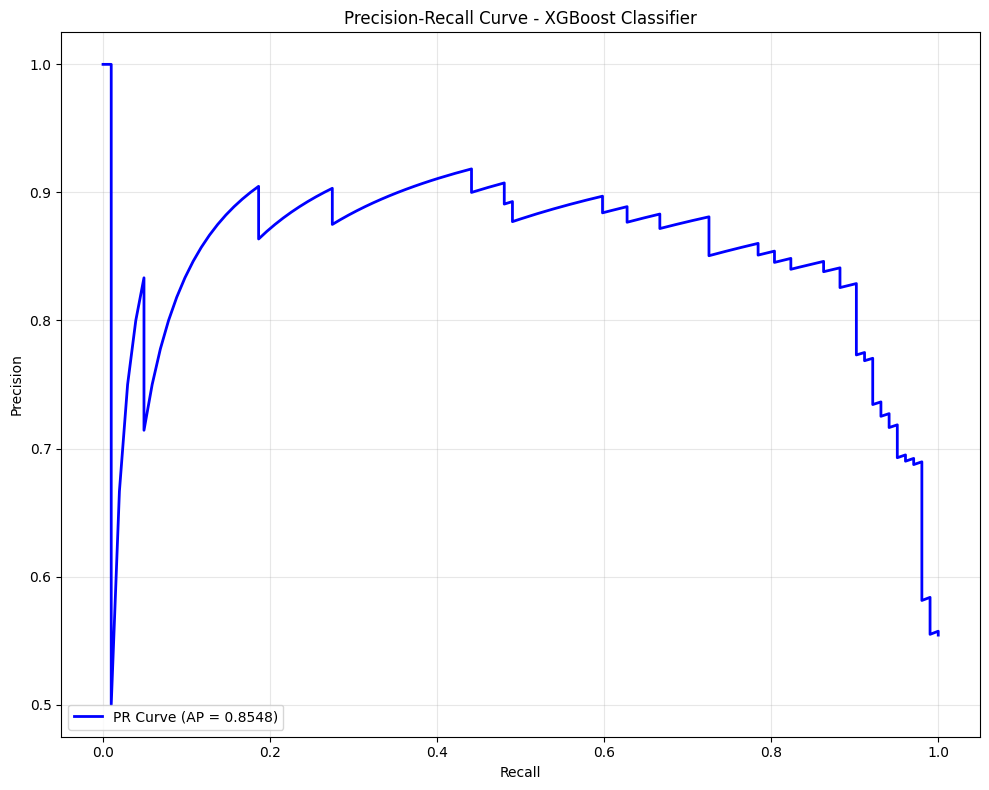

Precision-Recall Analysis:
Average Precision Score: 0.8548

Interpretation:
- Higher curve = better model performance
- Average Precision summarizes curve as weighted mean of precisions
- Useful for imbalanced datasets
- Score of 0.8548 indicates strong precision-recall tradeoff


In [39]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, thresholds_pr = precision_recall_curve(y_test, y_pred_proba_final)
avg_precision = average_precision_score(y_test, y_pred_proba_final)

plt.figure(figsize=(10, 8))
plt.plot(recall_vals, precision_vals, color='blue', lw=2, label=f'PR Curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - XGBoost Classifier')
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Precision-Recall Analysis:")
print("="*50)
print(f"Average Precision Score: {avg_precision:.4f}")
print("\nInterpretation:")
print("- Higher curve = better model performance")
print("- Average Precision summarizes curve as weighted mean of precisions")
print("- Useful for imbalanced datasets")
print(f"- Score of {avg_precision:.4f} indicates strong precision-recall tradeoff")

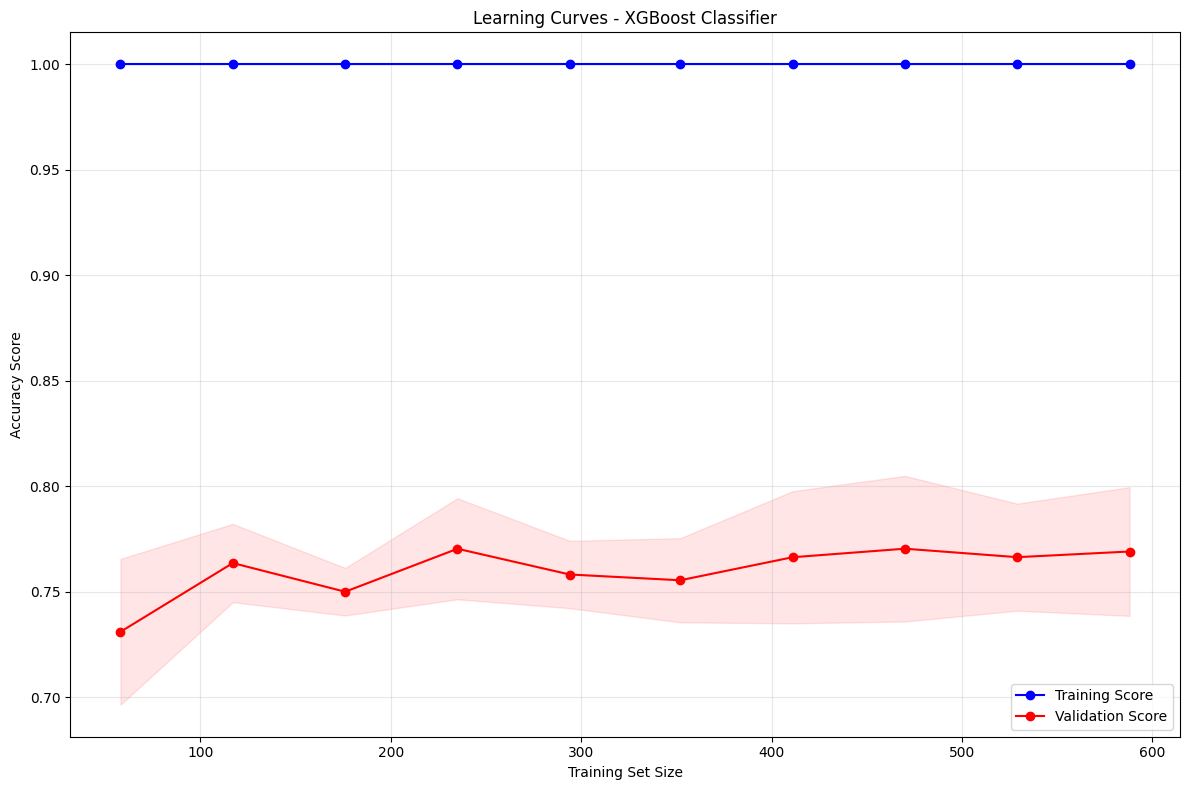

Learning Curve Analysis:
Final Training Score: 1.0000 ± 0.0000
Final Validation Score: 0.7690 ± 0.0305
Gap: 0.2310


In [42]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    X_train_scaled, y_train,
    cv=5,
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy',
    random_state=42
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(12, 8))
plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Score')
plt.plot(train_sizes, val_mean, 'o-', color='red', label='Validation Score')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='blue')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='red')

plt.xlabel('Training Set Size')
plt.ylabel('Accuracy Score')
plt.title('Learning Curves - XGBoost Classifier')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Learning Curve Analysis:")
print("="*50)
print(f"Final Training Score: {train_mean[-1]:.4f} ± {train_std[-1]:.4f}")
print(f"Final Validation Score: {val_mean[-1]:.4f} ± {val_std[-1]:.4f}")
print(f"Gap: {(train_mean[-1] - val_mean[-1]):.4f}")